# CellPin Tutorial

CellPin imputes the missing genes of spatially-resolved cells by leveraging a single-cell RNA reference data.  
This notebook walks through three complete workflows:

| Section | Description |
|---------|-------------|
| **A — Standard** | Train on all overlapping genes and impute the full reference gene space |
| **B — Held-out evaluation** | Hold out panel genes before training to benchmark imputation accuracy |

**Before running:** update the file paths in *Load data* cell to point to your own `.h5ad` files.

## Setup

In [1]:
import cellpin
import torch
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
import pandas as pd
from time import time
CONFIG_PATH = Path("configs/cellpin_config.yaml")
with CONFIG_PATH.open("r", encoding="utf-8") as f:
    MODEL_CONFIG = yaml.safe_load(f)

## Helper functions

Two evaluation helpers used throughout the notebook:

- `correlation_panel` — mean Pearson correlation between observed and imputed counts for the training panel genes  
- `correlation_heldout` — same metric, but restricted to genes that were **held out** during training (Option B only)

In [2]:
def correlation_panel(adata_imputed, layer_real, layer_imputed):
    """Mean per-gene Pearson r between two layers. Genes with -2 sentinel are excluded."""
    import scipy.sparse as sp

    counts_mat  = adata_imputed.layers[layer_real]
    imputed_mat = adata_imputed.layers[layer_imputed]
    if hasattr(counts_mat,  "toarray"): counts_mat  = counts_mat.toarray()
    if hasattr(imputed_mat, "toarray"): imputed_mat = imputed_mat.toarray()

    valid_idx = np.where(~(counts_mat == -2).any(axis=0))[0]
    pearsons = []
    for j in valid_idx:
        x, y = counts_mat[:, j], imputed_mat[:, j]
        if np.std(x) > 0 and np.std(y) > 0:
            pearsons.append(np.corrcoef(x, y)[0, 1])
        else:
            pearsons.append(np.nan)

    mean_r = np.nanmean(pearsons)
    print(f"Valid genes (no sentinel): {len(valid_idx)}")
    print(f"Mean Pearson r           : {mean_r:.4f}")


def correlation_heldout(adata_imputed, sp_adata_full, heldout_genes,
                        layer_real="counts", layer_imputed="imputed"):
    """Evaluate imputation accuracy on genes held out during training."""
    assert sp_adata_full.n_obs == adata_imputed.n_obs, \
        "Cell count mismatch between sp_adata_full and adata_imputed."

    pearsons = []
    for gene in heldout_genes:
        if gene not in sp_adata_full.var_names or gene not in adata_imputed.var_names:
            print(f"  [{gene}] not found — skipping")
            continue
        real    = sp_adata_full[:, gene].layers[layer_real].toarray().flatten().astype(float)
        imputed = adata_imputed[:, gene].layers[layer_imputed].toarray().flatten().astype(float)
        if np.std(real) == 0 or np.std(imputed) == 0:
            print(f"  [{gene}] zero variance — skipping")
            continue
        r = np.corrcoef(real, imputed)[0, 1]
        pearsons.append(r)
        print(f"  {gene:20s}  Pearson = {r:.4f}")

    mean_r = np.nanmean(pearsons)
    print(f"\nMean Pearson over {len(pearsons)} held-out genes: {mean_r:.4f}")


---
# A) Standard Workflow — Full Panel

The standard CellPin workflow in four steps:

1. Load a single-cell reference (`sc_adata`) and a spatial dataset (`sp_adata`)  
2. Run `cellpin.pp.setup()` to align gene spaces  
3. Train a `CellPin` model on the scRNA reference  
4. Impute the full gene space for every spatial cell  

All overlapping genes between the two datasets are used as panel input.

### A.1 — Load data

Both objects need raw integer counts — either in `.X` or in a named layer (set `LAYER` accordingly).

- `sc_adata`: single-cell reference atlas (full / highly-variable gene space)
- `sp_adata`: spatially-resolved dataset (panel genes only)

**Example data**

- Source dataset: [10x Genomics Xenium breast preview dataset](https://www.10xgenomics.com/products/xenium-in-situ/preview-dataset-human-breast)
- First described in: [Nature Communications (2023)](https://www.nature.com/articles/s41467-023-43458-x)
- Processing: data were processed according to standard single-cell best practices
- scRNA preprocessing: subset to Xenium panel genes plus 1,000 additional highly variable genes
- Spatial data: subsampled, with a normalized layer added
- Samples used:
  - Spatial: *In Situ Sample 1, Replicate 1*
  - Single-cell: *FRP*

In [3]:
LAYER = "counts"   # layer key with raw integer counts; set to None to use .X

sc_adata = cellpin.pp.load_sc_example()
sp_adata = cellpin.pp.load_sp_example()

print(f"sc_adata : {sc_adata.n_obs:,} cells × {sc_adata.n_vars:,} genes")
print(f"sp_adata : {sp_adata.n_obs:,} cells × {sp_adata.n_vars:,} spatial genes")

sc_adata : 23,867 cells × 1,307 genes
sp_adata : 30,600 cells × 313 spatial genes


### A.2 — Gene alignment check

Confirm which spatial genes are present in the scRNA reference before calling `setup()`.  
Any missing genes will be dropped automatically, but it is good to know upfront.

In [4]:
sc_genes = sc_adata.var_names
sp_genes = sp_adata.var_names

missing = sp_genes.difference(sc_genes)
if len(missing) == 0:
    print(f"All {len(sp_genes)} spatial genes are present in sc_adata ✓")
else:
    print(f"WARNING: {len(missing)} spatial gene(s) not in sc_adata (will be dropped by setup):")
    print(sorted(missing))

overlap = sp_genes.intersection(sc_genes)
print(f"\nPanel size (overlap)        : {len(overlap)} genes")
print(f"scRNA-only genes (to impute): {len(sc_genes) - len(overlap)} genes")

['AKR1C1', 'ANGPT2', 'BTNL9', 'CD8B', 'POLR2J3', 'TPSAB1']

Panel size (overlap)        : 307 genes
scRNA-only genes (to impute): 1000 genes


### A.3 — Setup and train

In [5]:
sc_dataset, sp_dataset = cellpin.pp.setup(sc_adata, sp_adata, layer=LAYER) #add batch_key="batch" if needed -recommended for reference atlases

[cellpin.pp.setup] Setting up CellPin datasets
[cellpin.pp.setup] sc_adata :   23,867 cells  ×    1,307 genes
[cellpin.pp.setup] st_adata :   30,600 cells  ×      313 spatial genes
[cellpin.pp.setup] Expression read from layer='counts'
[cellpin.pp.setup] WARNING: 6 spatial gene(s) not found in sc_adata — will be dropped:
  ['AKR1C1', 'ANGPT2', 'BTNL9', 'CD8B', 'POLR2J3', 'TPSAB1']
[cellpin.pp.setup] Panel    : 307 genes overlap (98.1% of spatial genes retained)
[cellpin.pp.setup] Imputed  : 1,307 genes total in sc space (1,000 genes to impute, not in panel)
[cellpin.pp.setup] sc_dataset: 23,867 cells, 1,307 genes total, 307 panel genes
[cellpin.pp.setup] st_dataset: 30,600 cells, 307 panel genes


In [6]:
time_start = time()
model_A = cellpin.CellPin(sc_dataset, config=MODEL_CONFIG)
model_A.fit(sc_dataset, pretrain_epochs=50, train_epochs=60,save_checkpoints=False) #save_checkpoints=True is much slower and not needed for this tutorial
print(f"Training time: {(time() - time_start)/60:.2f} minutes")

Epoch 59: 100%|██████████| 75/75 [00:03<00:00, 21.38it/s, v_num=67, val_loss=518.0, val_reconst_loss=434.0, val_kl_loss=55.30, val_kl_l_loss=2.480, val_distill_loss=0.0688, val_snn_loss=1.540, val_inv_loss=0.200, val_snn_temperature=0.104, val_pearson_loss=0.469, train_loss=517.0, train_reconst_loss=432.0, train_kl_loss=58.90, train_kl_l_loss=2.520, train_distill_loss=0.0803, train_snn_loss=1.630, train_inv_loss=0.219, train_snn_temperature=0.104, train_pearson_loss=0.435]
Training time: 6.10 minutes


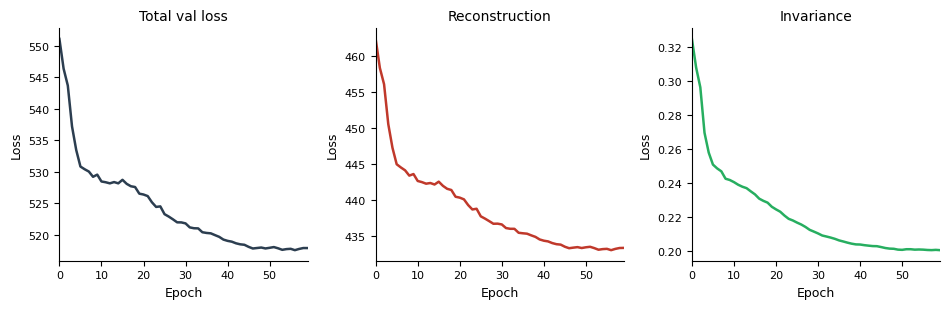

In [7]:
model_A.pl.losses(smooth=5)

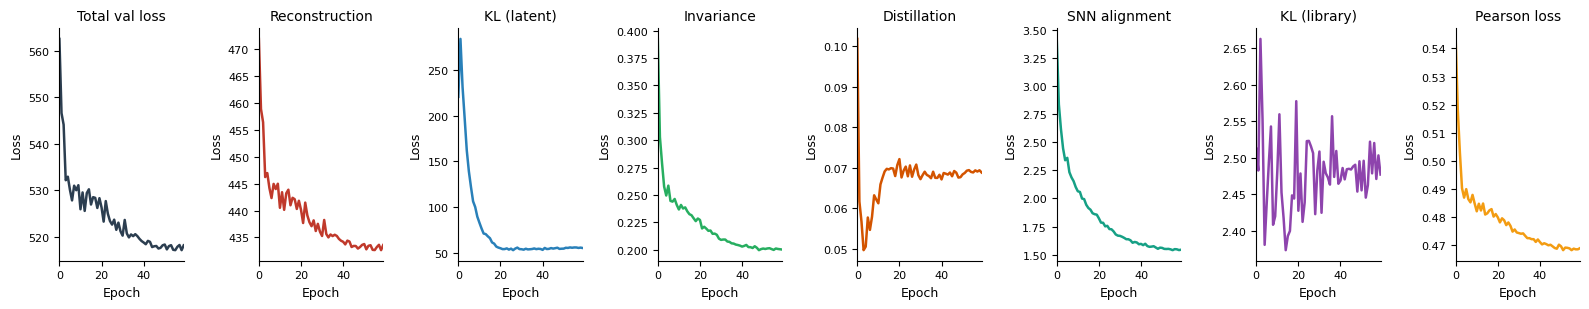

In [8]:
model_A.pl.losses(keys="all")   

### A.4 — Impute

`return_norm=True` adds an area-normalised log1p layer (`imputed_norm`).  
Set `area_key=None` if your spatial data has no `cell_area` column.

In [9]:
time_start = time()
dl_A = torch.utils.data.DataLoader(sp_dataset, batch_size=512, shuffle=False)

adata_imputed_A = model_A.impute(
    dl_A,
    obs_adata=sp_adata,
    return_norm=True,
    area_key="cell_area",
    nb_count_samples=20,
)
print(f"Imputation time: {(time() - time_start)/60:.2f} minutes")
print(adata_imputed_A)

Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓
  [impute] Filling 1000 gene(s) absent from obs_adata layers with sentinel -2.0
  [impute] Filling 1000 gene(s) absent from obs_adata layers with sentinel -2.0
Imputation time: 1.15 minutes
AnnData object with n_obs × n_vars = 30600 × 1307
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    obsm: 'X_cellpin', 'spatial'
    layers: 'counts', 'log1p_norm', 'imputed', 'imputed_norm'


### A.5 — Evaluate

Pearson correlation between observed and imputed counts for panel genes.

In [10]:
print("=== Count space ===")
correlation_panel(adata_imputed_A, layer_real="counts", layer_imputed="imputed")

print("\n=== Log-normalised space ===")
correlation_panel(adata_imputed_A, layer_real="log1p_norm", layer_imputed="imputed_norm")

=== Count space ===
Valid genes (no sentinel): 307
Mean Pearson r           : 0.5948

=== Log-normalised space ===
Valid genes (no sentinel): 307
Mean Pearson r           : 0.5016


### A.6 — Visualise

Spatial maps and UMAP for a few marker genes.  
`MS4A1` and `CD19` were in the panel; `FCRL1` and `PAX5` are purely imputed. (All B cell genes, expected to co-localise)

/tmp/ipykernel_418739/4247071269.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_A, layer="imputed_norm", color=GENE,


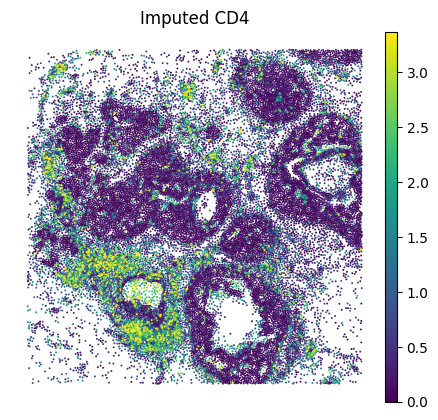

/tmp/ipykernel_418739/4247071269.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_A, layer="log1p_norm",   color=GENE,


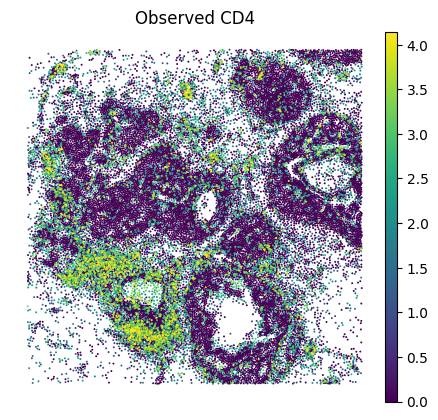

In [11]:
GENE = "CD4"   # edit as needed

sc.pl.spatial(adata_imputed_A, layer="imputed_norm", color=GENE,
              spot_size=15, vmax="p99", frameon=False, title=f"Imputed {GENE}")
sc.pl.spatial(adata_imputed_A, layer="log1p_norm",   color=GENE,
              spot_size=15, vmax="p99", frameon=False, title=f"Observed {GENE}")

Spatial plots — B-cell markers:


/tmp/ipykernel_418739/1331889655.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_A, layer="imputed_norm", color=bcells,


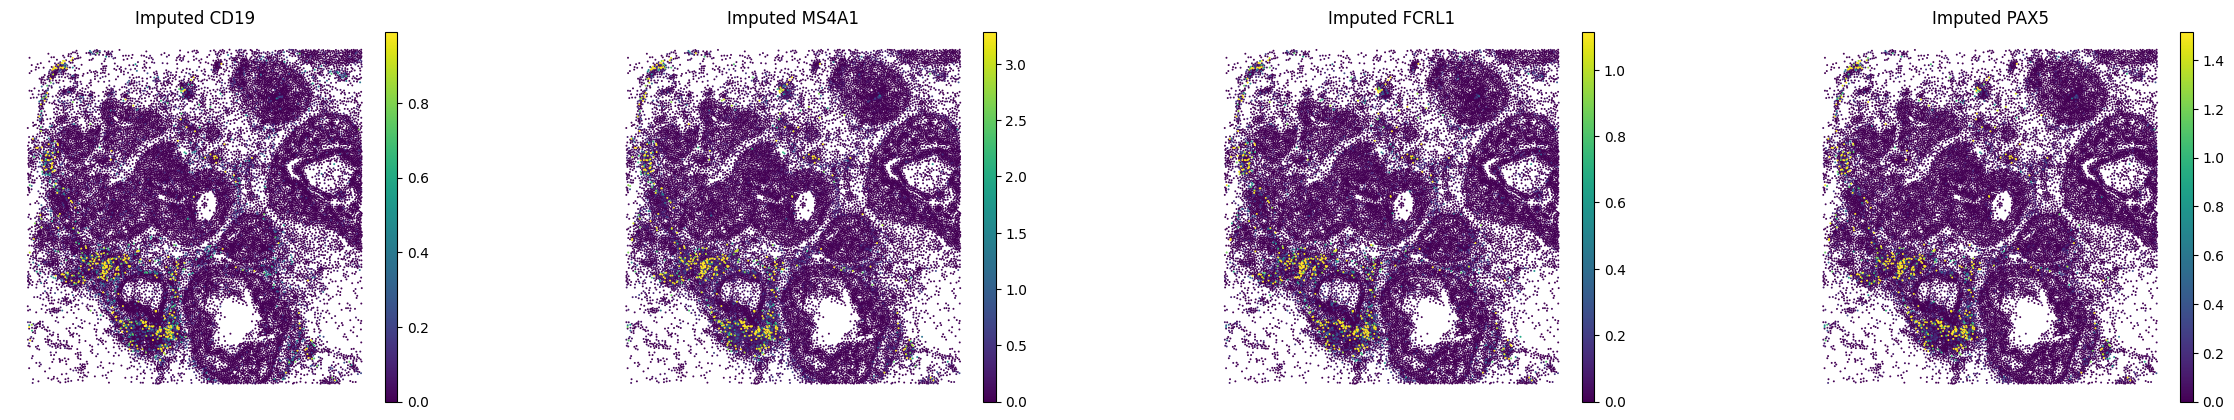

/tmp/ipykernel_418739/1331889655.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_A, layer="log1p_norm",   color=bcells,


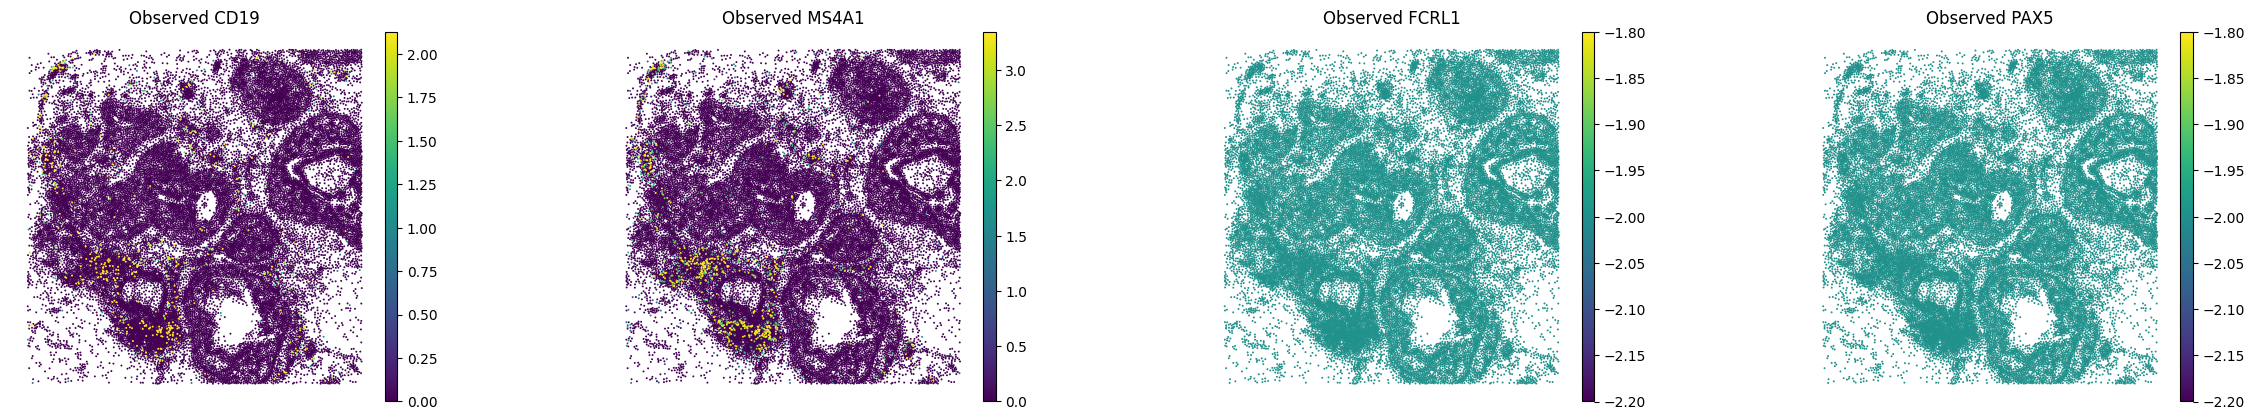

In [12]:
bcells = ["CD19", "MS4A1", "FCRL1", "PAX5"]

print("Spatial plots — B-cell markers:")
sc.pl.spatial(adata_imputed_A, layer="imputed_norm", color=bcells,
              spot_size=15, vmax="p99", frameon=False, title=[f"Imputed {g}" for g in bcells])
sc.pl.spatial(adata_imputed_A, layer="log1p_norm",   color=bcells,
              spot_size=15, vmax="p99", frameon=False, title=[f"Observed {g}" for g in bcells])

### A.7 — UMAP from CellPin embeddings

Cell embeddings in `obsm["X_cellpin"]` can be used directly to build a neighborhood graph and compute a UMAP

UMAP — B-cell markers:


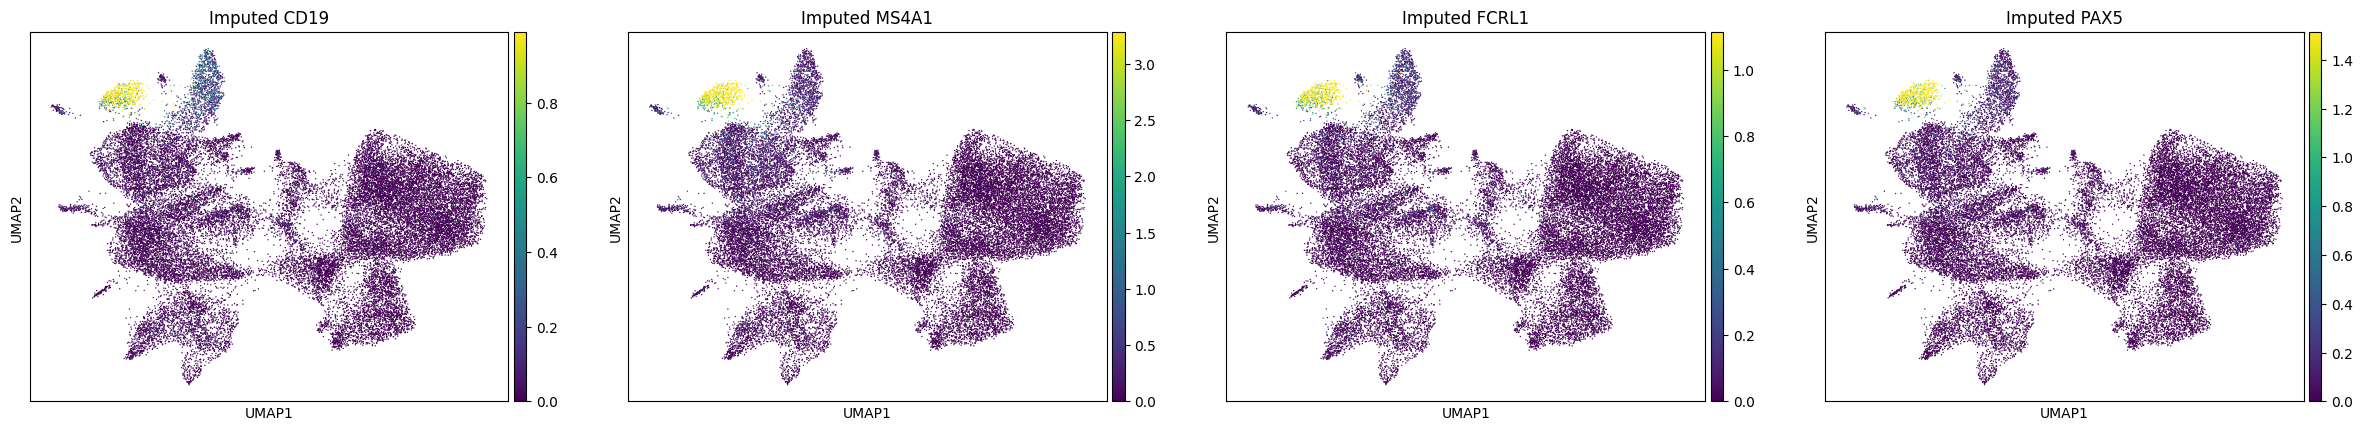

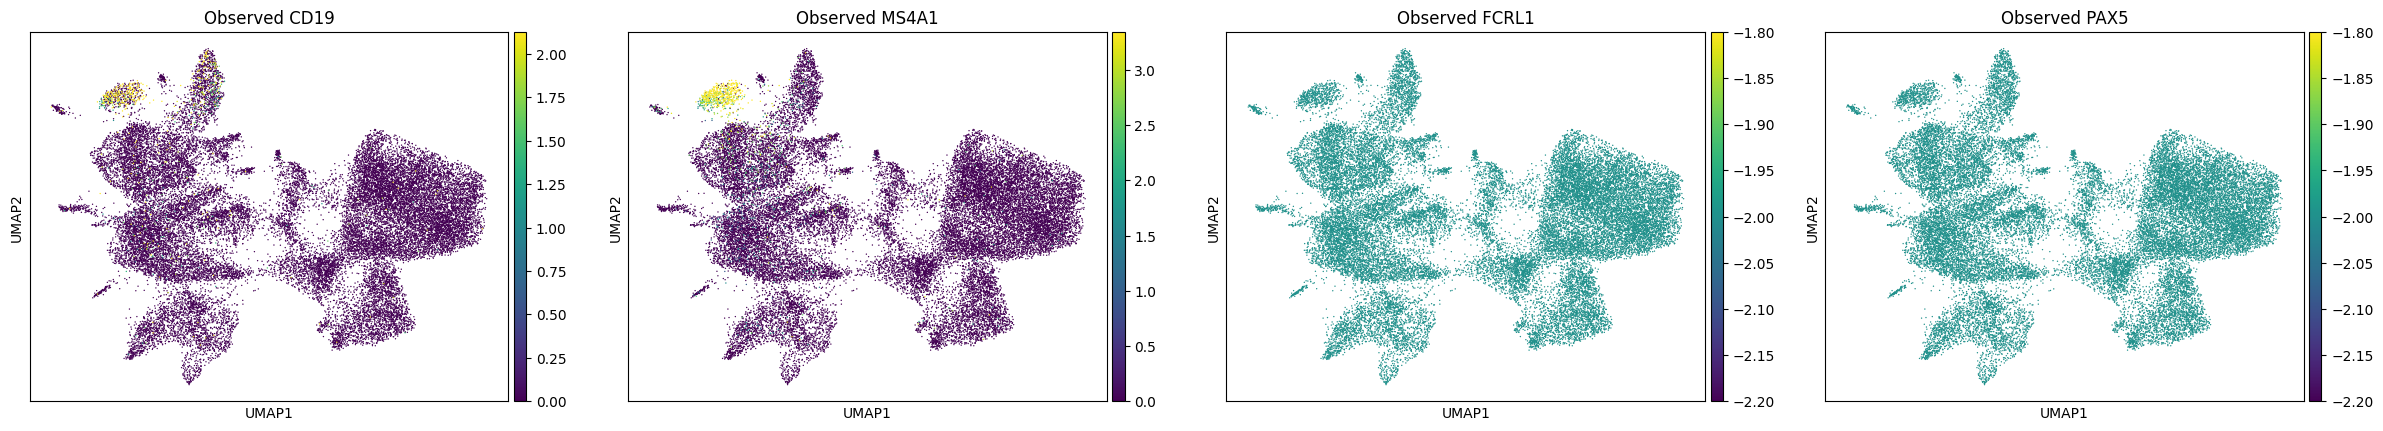

In [13]:
sc.pp.neighbors(adata_imputed_A, use_rep="X_cellpin")
sc.tl.umap(adata_imputed_A)

print("UMAP — B-cell markers:")
sc.pl.umap(adata_imputed_A, color=bcells, layer="imputed_norm", vmax="p99",
           title=[f"Imputed {g}" for g in bcells])
sc.pl.umap(adata_imputed_A, color=bcells, layer="log1p_norm",   vmax="p99",
           title=[f"Observed {g}" for g in bcells])

---
# B) Held-Out Gene Evaluation

To benchmark how well CellPin imputes genes it has never seen during training, we:

1. Randomly sample a fraction of panel genes as **held-out genes**  
2. Remove them from the spatial input before `setup()`  
3. Train and impute as normal  
4. Compare imputed values against the ground-truth counts for those held-out genes  

The held-out Pearson correlation is the most honest imputation benchmark.

### B.1 — Define held-out genes

In [14]:
rng = np.random.default_rng(42)

# Panel genes in sc_adata order — consistent with setup()'s internal ordering
panel_genes_all = [g for g in sc_adata.var_names if g in set(sp_adata.var_names)]
print(f"Full panel size: {len(panel_genes_all)} genes")

HOLDOUT_FRACTION = 0.10   # hold out 10 % of the panel
n_holdout     = max(1, int(len(panel_genes_all) * HOLDOUT_FRACTION))
heldout_genes = rng.choice(panel_genes_all, size=n_holdout, replace=False).tolist()
training_genes = [g for g in panel_genes_all if g not in heldout_genes]

print(f"Held-out genes : {n_holdout}  → {heldout_genes[:5]} ...")
print(f"Training panel : {len(training_genes)} genes")

Full panel size: 307 genes
Held-out genes : 30  → ['NDUFA4L2', 'CCDC6', 'LEP', 'CCL8', 'ELF3'] ...
Training panel : 277 genes


In [15]:
# Build the reduced spatial object (held-out genes removed)
sp_adata_reduced = sp_adata[:, training_genes].copy()

assert len(set(heldout_genes) & set(sp_adata_reduced.var_names)) == 0, \
    "Held-out genes still present in reduced sp_adata!"
print(f"sp_adata_reduced: {sp_adata_reduced.n_obs:,} cells × {sp_adata_reduced.n_vars:,} genes (held-out genes removed ✓)")

sp_adata_reduced: 30,600 cells × 277 genes (held-out genes removed ✓)


### B.2 — Setup and train

In [16]:
sc_dataset_B, sp_dataset_B = cellpin.pp.setup(sc_adata, sp_adata_reduced, layer=LAYER)

[cellpin.pp.setup] Setting up CellPin datasets
[cellpin.pp.setup] sc_adata :   23,867 cells  ×    1,307 genes
[cellpin.pp.setup] st_adata :   30,600 cells  ×      277 spatial genes
[cellpin.pp.setup] Expression read from layer='counts'
[cellpin.pp.setup] Panel    : 277 genes overlap (100.0% of spatial genes retained)
[cellpin.pp.setup] Imputed  : 1,307 genes total in sc space (1,030 genes to impute, not in panel)
[cellpin.pp.setup] sc_dataset: 23,867 cells, 1,307 genes total, 277 panel genes
[cellpin.pp.setup] st_dataset: 30,600 cells, 277 panel genes


In [17]:
model_B = cellpin.CellPin(sc_dataset_B, config=MODEL_CONFIG)
model_B.fit(sc_dataset_B, pretrain_epochs=50, train_epochs=60,save_checkpoints=False) #save_checkpoints=True is much slower and not needed for this tutorial

Epoch 59: 100%|██████████| 75/75 [00:05<00:00, 14.12it/s, v_num=68, val_loss=522.0, val_reconst_loss=437.0, val_kl_loss=56.30, val_kl_l_loss=2.470, val_distill_loss=0.0734, val_snn_loss=1.650, val_inv_loss=0.213, val_snn_temperature=0.105, val_pearson_loss=0.470, train_loss=521.0, train_reconst_loss=435.0, train_kl_loss=59.60, train_kl_l_loss=2.520, train_distill_loss=0.0845, train_snn_loss=1.710, train_inv_loss=0.230, train_snn_temperature=0.105, train_pearson_loss=0.439]


### B.3 — Impute

In [18]:
dl_B = torch.utils.data.DataLoader(sp_dataset_B, batch_size=512, shuffle=False)

adata_imputed_B = model_B.impute(
    dl_B,
    obs_adata=sp_adata_reduced,
    return_norm=True,
    area_key="cell_area",
    nb_count_samples=20,
)
print(adata_imputed_B)

Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓
  [impute] Filling 1030 gene(s) absent from obs_adata layers with sentinel -2.0
  [impute] Filling 1030 gene(s) absent from obs_adata layers with sentinel -2.0
AnnData object with n_obs × n_vars = 30600 × 1307
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    obsm: 'X_cellpin', 'spatial'
    layers: 'counts', 'log1p_norm', 'imputed', 'imputed_norm'


### B.4 — Evaluate

Two metrics:
- **Panel Pearson** — reconstruction quality on the training genes (sanity check)  
- **Held-out Pearson** — true imputation benchmark on genes the model never saw

In [19]:
print("=== Training panel genes (count space) ===")
correlation_panel(adata_imputed_B, layer_real="counts", layer_imputed="imputed")

=== Training panel genes (count space) ===
Valid genes (no sentinel): 277
Mean Pearson r           : 0.5991


In [20]:
print("=== Held-out genes — count space ===")
correlation_heldout(
    adata_imputed_B,
    sp_adata_full=sp_adata,          # sp_adata (full) has ground-truth counts for held-out genes
    heldout_genes=heldout_genes,
    layer_real="counts",
    layer_imputed="imputed",
)

=== Held-out genes — count space ===
  NDUFA4L2              Pearson = 0.1948
  CCDC6                 Pearson = 0.6159
  LEP                   Pearson = 0.3355
  CCL8                  Pearson = 0.1998
  ELF3                  Pearson = 0.6560
  ENAH                  Pearson = 0.4556
  TIMP4                 Pearson = 0.3062
  KRT14                 Pearson = 0.8055
  ITGAX                 Pearson = 0.7653
  LYZ                   Pearson = 0.7714
  GNLY                  Pearson = 0.5695
  CX3CR1                Pearson = 0.4721


  SPIB                  Pearson = 0.3976
  CXCL12                Pearson = 0.8382
  KRT23                 Pearson = 0.8347
  DNAAF1                Pearson = 0.0604
  AGR3                  Pearson = 0.6239
  FOXA1                 Pearson = 0.8617
  FOXP3                 Pearson = 0.3210
  PTN                   Pearson = 0.7683
  PDCD1LG2              Pearson = 0.2206
  CCND1                 Pearson = 0.7912
  SQLE                  Pearson = 0.4583
  ANKRD30A              Pearson = 0.8561
  SERPINA3              Pearson = 0.7565
  CEACAM8               Pearson = -0.0548
  GPR183                Pearson = 0.5225
  CLECL1                Pearson = 0.2645
  LILRA4                Pearson = 0.7325
  CCPG1                 Pearson = 0.4692

Mean Pearson over 30 held-out genes: 0.5290


In [21]:
print("=== Held-out genes — log-normalised space ===")
correlation_heldout(
    adata_imputed_B,
    sp_adata_full=sp_adata,
    heldout_genes=heldout_genes,
    layer_real="log1p_norm",
    layer_imputed="imputed_norm",
)

=== Held-out genes — log-normalised space ===
  NDUFA4L2              Pearson = 0.1694
  CCDC6                 Pearson = 0.4945
  LEP                   Pearson = 0.1270
  CCL8                  Pearson = 0.1635
  ELF3                  Pearson = 0.6404
  ENAH                  Pearson = 0.3344
  TIMP4                 Pearson = 0.0869
  KRT14                 Pearson = 0.7460
  ITGAX                 Pearson = 0.5889
  LYZ                   Pearson = 0.6436
  GNLY                  Pearson = 0.4153
  CX3CR1                Pearson = 0.3974
  SPIB                  Pearson = 0.3569
  CXCL12                Pearson = 0.7531
  KRT23                 Pearson = 0.7155
  DNAAF1                Pearson = 0.0302
  AGR3                  Pearson = 0.5758
  FOXA1                 Pearson = 0.8442
  FOXP3                 Pearson = 0.3040
  PTN                   Pearson = 0.7031
  PDCD1LG2              Pearson = 0.1451
  CCND1                 Pearson = 0.6937
  SQLE                  Pearson = 0.3280
  ANKRD30A 

### B.5 — Visualise held-out genes

Compare imputed vs. observed spatial expression for a few held-out genes with strong Pearson correlation.

/tmp/ipykernel_418739/3482941651.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_B, layer="imputed_norm", color=GENES_HELDOUT,


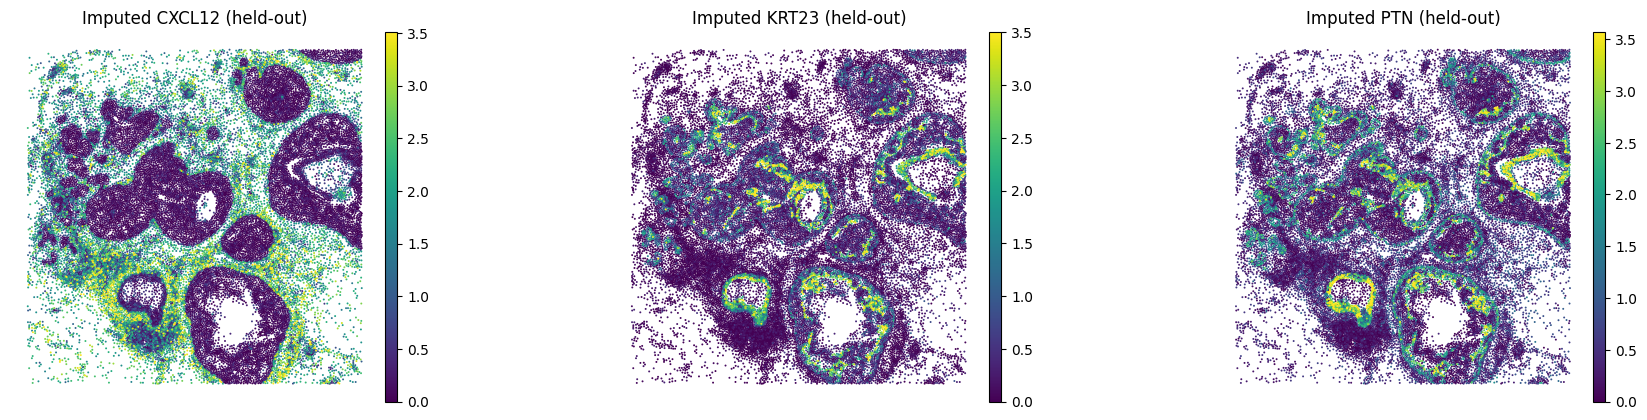

/tmp/ipykernel_418739/3482941651.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sp_adata, layer="log1p_norm", color=GENES_HELDOUT,


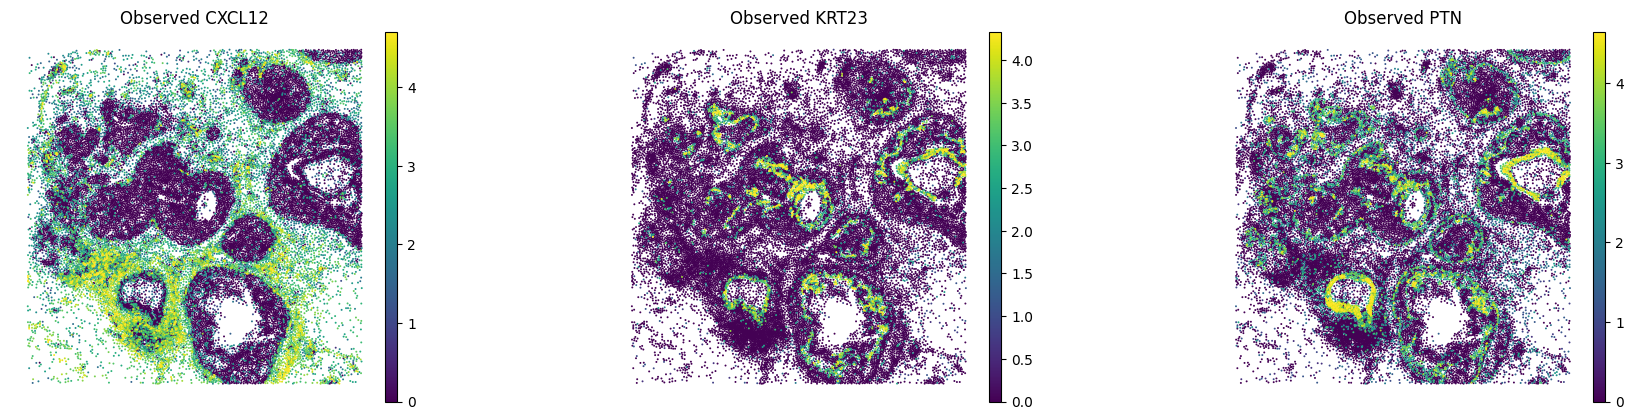

In [22]:
# Edit: pick held-out genes with high Pearson from the evaluation above
GENES_HELDOUT = ["CXCL12", "KRT23", "PTN"]

sc.pl.spatial(adata_imputed_B, layer="imputed_norm", color=GENES_HELDOUT,
              spot_size=15, vmax="p99", frameon=False,
              title=[f"Imputed {g} (held-out)" for g in GENES_HELDOUT])
sc.pl.spatial(sp_adata, layer="log1p_norm", color=GENES_HELDOUT,
              spot_size=15, vmax="p99", frameon=False,
              title=[f"Observed {g}" for g in GENES_HELDOUT])